#PROJECT TITLE: Natural Language Programming (NLP) For SMS Spam Detection and Web Application

##**Overview**

The SMS Spam Collection is a set of SMS tagged messages that have been collected for SMS Spam research. It contains one set of SMS messages in English of 5,574 messages, tagged acording being ham (not spam/legitimate) or spam.

##Objectives:

- To build a model that detects spams forn sms (text messages) and deploy it into a web application (streamlit app).

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


1. Load Data

In [92]:
text_df = pd.read_csv("/content/drive/MyDrive/spam.csv", encoding="latin-1")[["v1", "v2"]]
text_df.columns = ["label", "message"]
text_df. head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


2. Understanding the Data

In [93]:
text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


The dataframe has 5572 entries (rows) and 2 columns. There are no missing values and their data types are the right one for each column.

In [94]:
text_df['label'].value_counts()

,count
label,
ham,4825
spam,747


* ham (no spam) has more counts of 4825 than spam count of 747.


3. EDA and Advanced Visualization

Text(0, 0.5, 'Count')

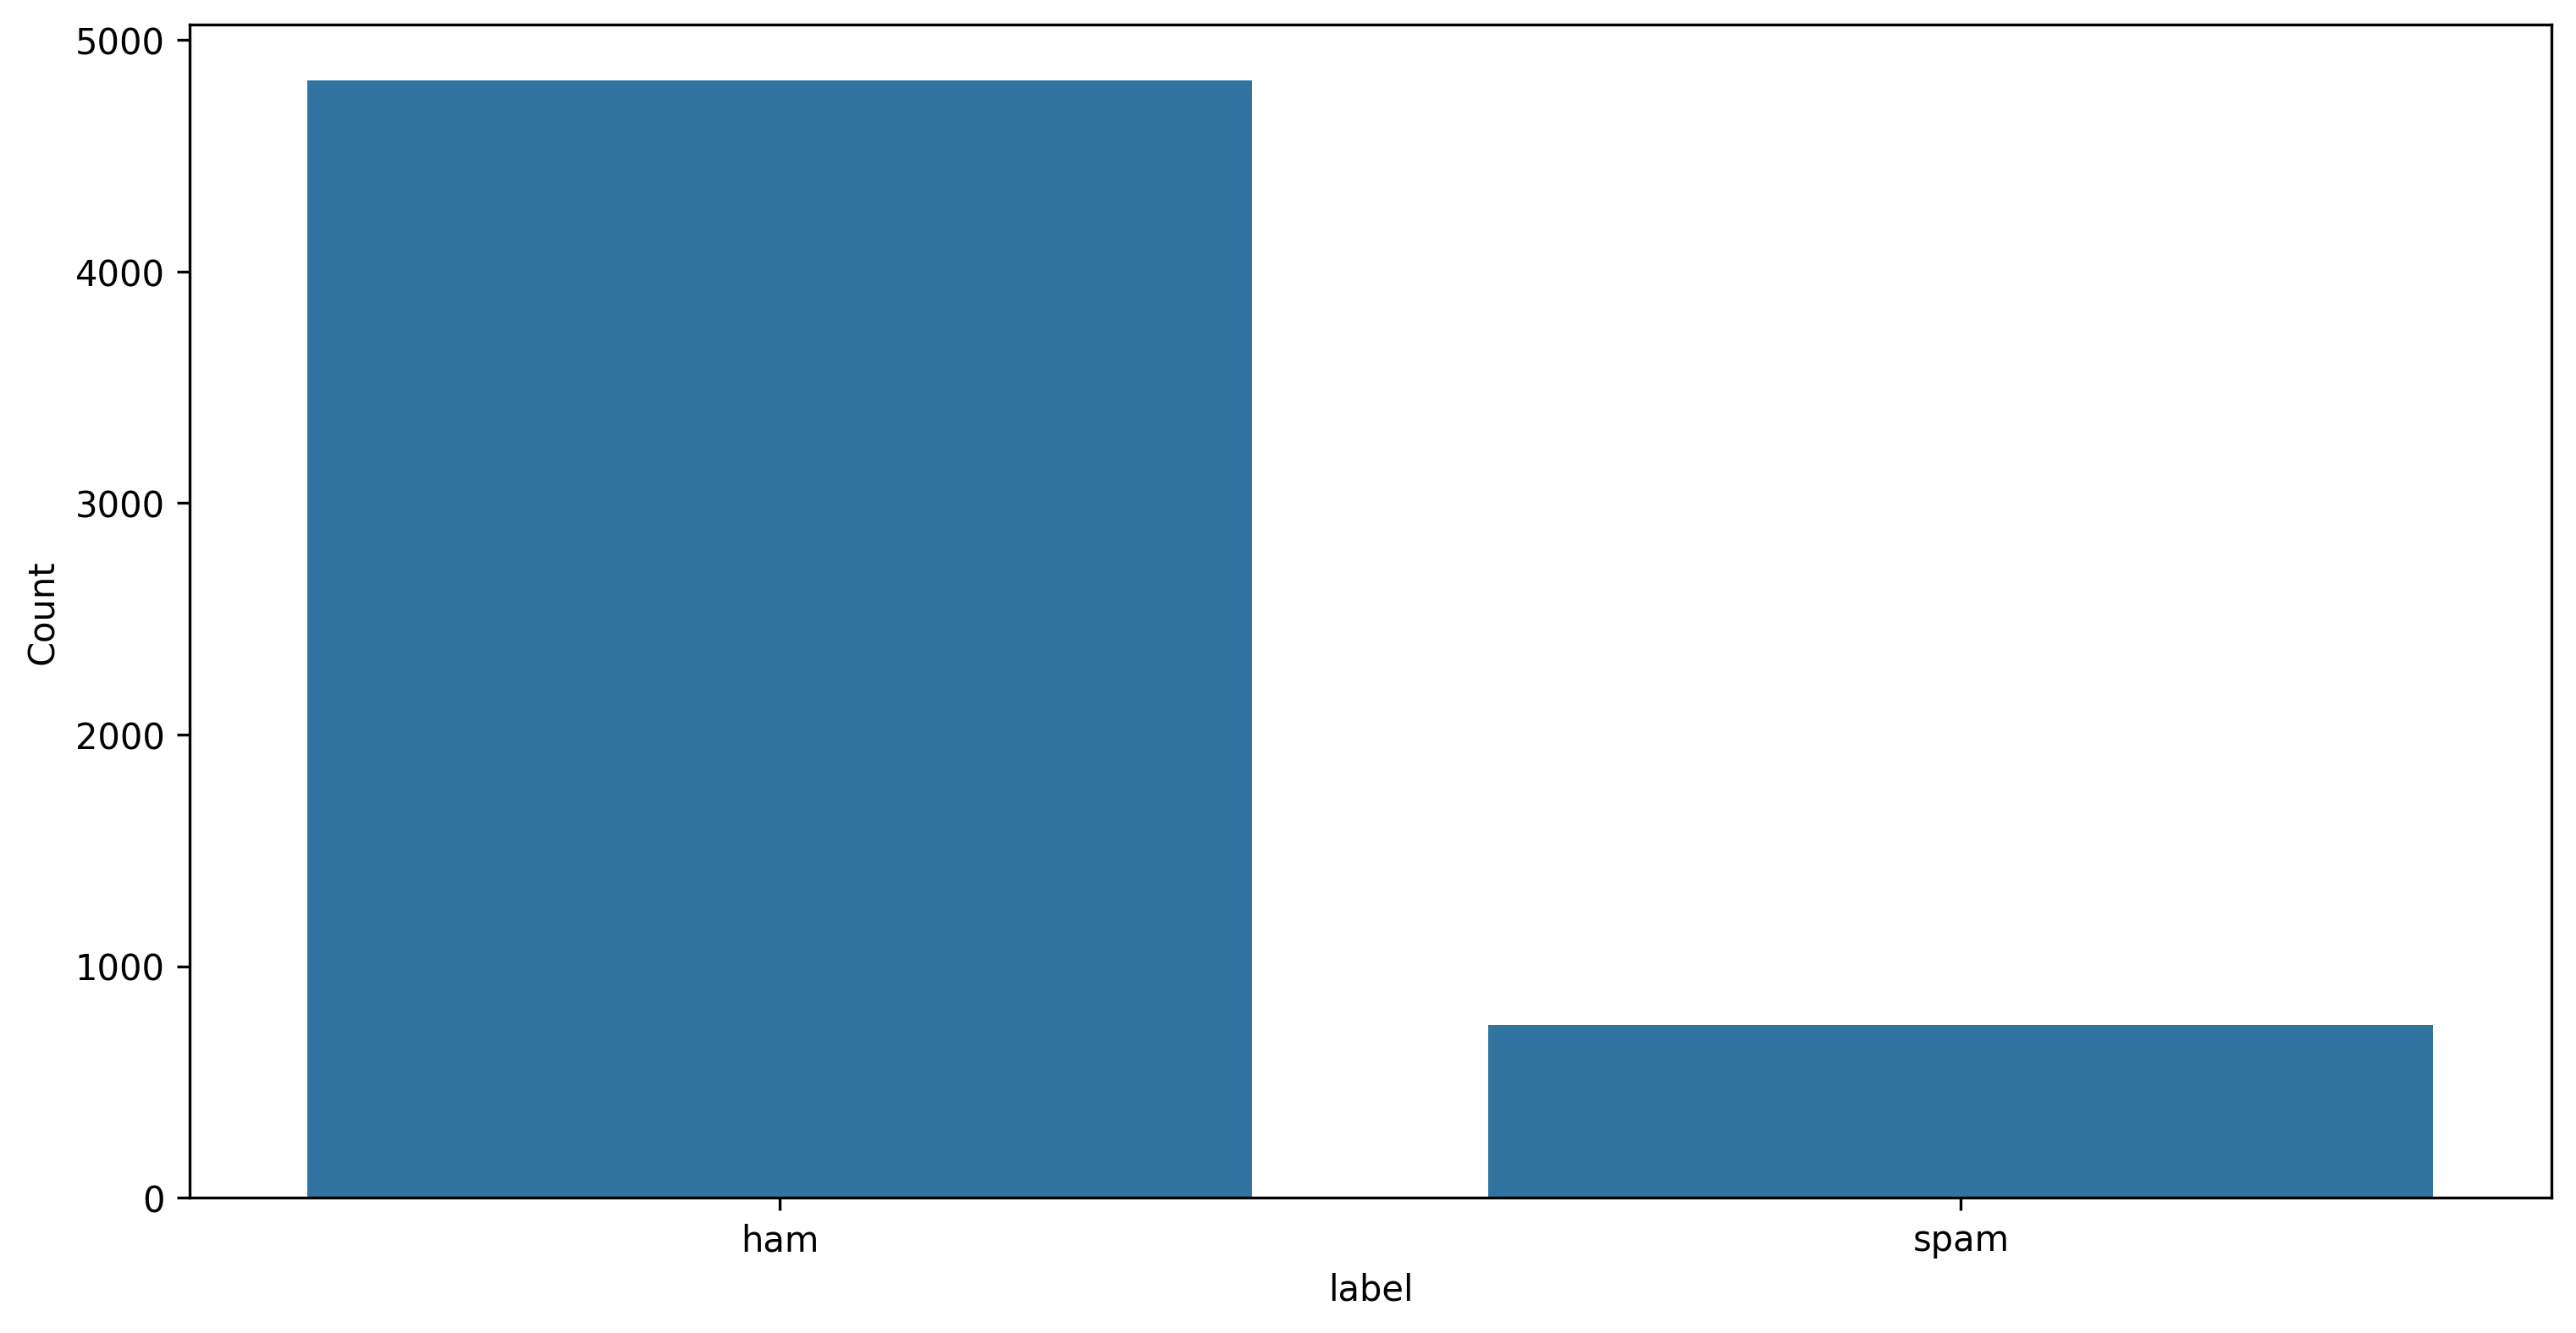

In [95]:
#Visualize the ham and spam count
plt.figure(figsize=(12, 6), dpi=300)

sns.countplot(x = text_df['label'])
plt.xlabel('label')
plt.ylabel('Count')


* This shows how imbalanced this dataset is.

In [96]:
#function
def word(text):
    return len(text.split(" "))

text_df['word_length'] = text_df['message'].apply(word)

print("--- DataFrame with Word Lengths ---")
print(text_df)

print("\n--- Word Length Column ---")
print(text_df['word_length'])


--- DataFrame with Word Lengths ---
     label                                            message  word_length
0      ham  Go until jurong point, crazy.. Available only ...           20
1      ham                      Ok lar... Joking wif u oni...            6
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...           28
3      ham  U dun say so early hor... U c already then say...           11
4      ham  Nah I don't think he goes to usf, he lives aro...           13
...    ...                                                ...          ...
5567  spam  This is the 2nd time we have tried 2 contact u...           30
5568   ham              Will Ì_ b going to esplanade fr home?            8
5569   ham  Pity, * was in mood for that. So...any other s...           10
5570   ham  The guy did some bitching but I acted like i'd...           26
5571   ham                         Rofl. Its true to its name            6

[5572 rows x 3 columns]

--- Word Length Column ---
0       20


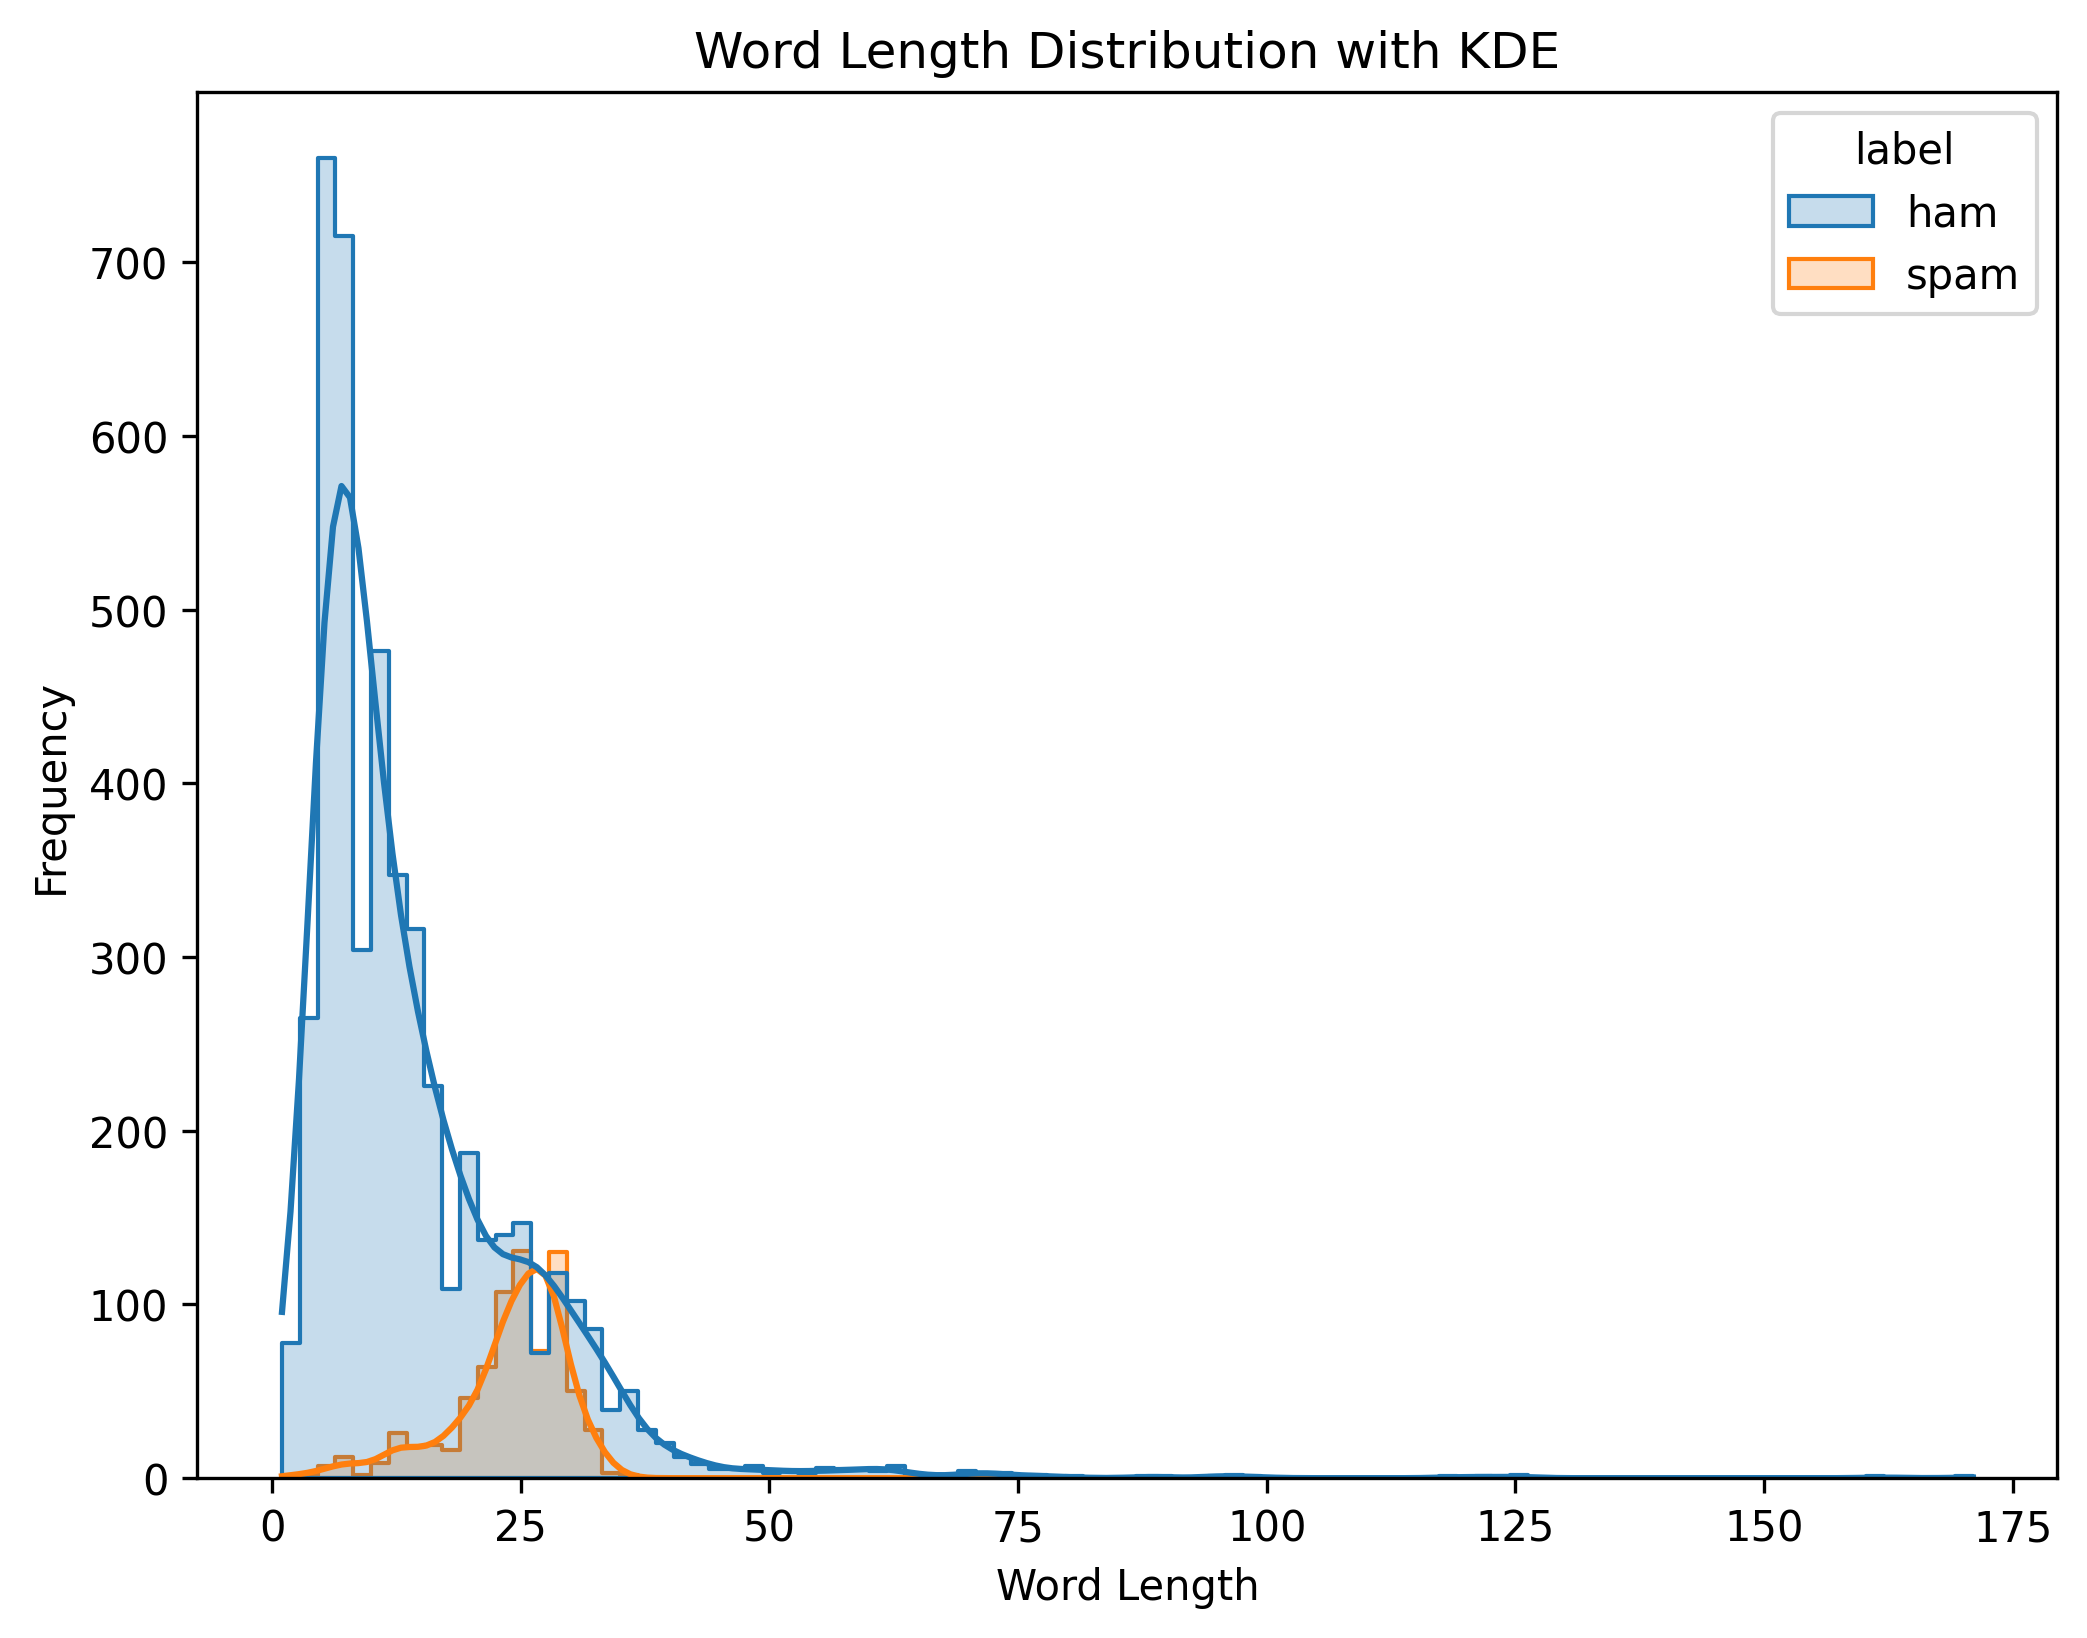

In [97]:
plt.figure(figsize=(8, 6), dpi=300)

sns.histplot(data=text_df, x='word_length', hue='label', kde=True, element='step')
plt.title('Word Length Distribution with KDE')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.show()

* Ham messages (no spam) has a high frequency of word length while spam has a short frequency of word length. This is because ham messages tend to be more conversational and explanatory, while spam messages are concise, urgent, or designed to be read quickly so that an action can be made.

4. Preprocessing

In [98]:
#Download necessary NLTK data (run these once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def text_preprocessing_df(df):
    processed_messages = [] # To store the processed string messages
    tokenized_messages = [] # To store the lists of tokenized words

    for i in range(len(df)):
        # Get the message to process. Note: if text_df was already processed by a previous cell,
        # this will re-process the already cleaned message. For a clean run,
        # ensure text_df is in its original state before calling this function.
        message_to_process = df.loc[i, "message"]
        review = re.sub("[^a-zA-Z]", " ", message_to_process) # keep only alphabets

        # Use word_tokenize for better tokenization than simple split()
        review_words = word_tokenize(review)

        # lemmatize and remove stopwords
        processed_words_list = [lemmatizer.lemmatize(word.lower()) for word in review_words if word.lower() not in stop_words]

        # Store the list of processed tokens
        tokenized_messages.append(processed_words_list)

        # Create the processed string message for the 'message' column
        processed_string_message = " ".join(processed_words_list)
        processed_messages.append(processed_string_message)

    # Assign the collected lists to the new columns outside the loop
    df['tokenized_message'] = tokenized_messages
    df['message'] = processed_messages # Update the message column with processed strings
    return df

df = text_preprocessing_df(text_df)

print(df.tail())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


     label                                            message  word_length  \
5567  spam  nd time tried contact u u pound prize claim ea...           30   
5568   ham                          b going esplanade fr home            8   
5569   ham                               pity mood suggestion           10   
5570   ham  guy bitching acted like interested buying some...           26   
5571   ham                                     rofl true name            6   

                                      tokenized_message  
5567  [nd, time, tried, contact, u, u, pound, prize,...  
5568                    [b, going, esplanade, fr, home]  
5569                           [pity, mood, suggestion]  
5570  [guy, bitching, acted, like, interested, buyin...  
5571                                 [rofl, true, name]  


3.1. Binary Encoding

In [99]:
df["label"] = df['label'].map({"ham":0, "spam":1})
df.head()

,label,message,word_length,tokenized_message
0,0,go jurong point crazy available bugis n great ...,20,"[go, jurong, point, crazy, available, bugis, n..."
1,0,ok lar joking wif u oni,6,"[ok, lar, joking, wif, u, oni]"
2,1,free entry wkly comp win fa cup final tkts st ...,28,"[free, entry, wkly, comp, win, fa, cup, final,..."
3,0,u dun say early hor u c already say,11,"[u, dun, say, early, hor, u, c, already, say]"
4,0,nah think go usf life around though,13,"[nah, think, go, usf, life, around, though]"


In [100]:
 #Vectorization (TF-IDF)
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(text_df['message']).toarray()
y = df['label'].values

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [101]:
# Model Training (Naive Bayes)
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Evaluation
y_pred = log_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(report)

Accuracy: 0.9561
Confusion Matrix:
[[961   4]
 [ 45 105]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       0.96      0.70      0.81       150

    accuracy                           0.96      1115
   macro avg       0.96      0.85      0.89      1115
weighted avg       0.96      0.96      0.95      1115



Interpretation:
- I chose to use the logistic regression model because it is a classificaion  supervised machine learning model.

* Accuracy for this model was 96% which shows that the model was able to accurately predict messages into spam or not spam (ham).

* Precision for this  model was 96% wh

In [ ]:
#visualize the confusion matrix

